# Evaluación 1

**Integrante 1:** Claudio Gaete Flores

**Integrante 2:** Juan Loyola Lagos

**Correo Electrónico integrante 1:** claudio.gaete2301@alumnos.ubiobio.cl

**Correo Electrónico integrante 2:** juan.loyola2301@alumnos.ubiobio.cl

**Fecha de Creación:** 17 Abril de 2026  
**Versión:** 1.0  

---

## Descripción

Este notebook contiene el desarrollo de la evaluación 1 de la asignatura Inteligencia Artificial de la carrera de Ingeniería Civil en Informática de la Universidad del Bio Bio, sede Concepción.
Incluye pasos de análisis de variables, revisión de limpieza, implementación de Pipeline de limpieza y transformación y guardado de dataset limpio.

---

## Requisitos de Software

Este notebook fue desarrollado con Python 3.12. A continuación se listan las bibliotecas necesarias:

- pandas (>=1.1.0)
- matplotlib (3.7.1)
- numpy (2.0.2)


Para verificar la versión instalada ejecutar usando el siguiente comando, usando la librería de la cual quieres saber la versión:

```python
import pandas as pd
print(pd.__version__)
```

# Carga de datos

In [1]:
!wget https://raw.githubusercontent.com/JaznaLaProfe/datos/master/preparation_data/dataset_churn_dirty.csv

--2026-04-17 02:42:15--  https://raw.githubusercontent.com/JaznaLaProfe/datos/master/preparation_data/dataset_churn_dirty.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2771759 (2.6M) [text/plain]
Saving to: ‘dataset_churn_dirty.csv’

dataset_churn_dirty 100%[===================>]   2.64M  --.-KB/s    in 0.1s    

2026-04-17 02:42:17 (23.2 MB/s) - ‘dataset_churn_dirty.csv’ saved [2771759/2771759]



## Importación de librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder

## Descripción datos

Dataset de clientes de una plataforma de suscripción digital, diseñado para tareas de preparación de datos y modelado predictivo de abandono \(churn\)\. 

### Variables Numéricas

- customer\_id: Id del cliente

- age: Edad cliente en años 

- monthly\_income: Sueldo mensual estimado en CLP

- tenure\_months: Antigüedad del cliente en la plataforma en meses

- num\_logins\_last\_month: Número de accesos en el último mes

- avg\_session\_time: Tiempo promedio de sesión en minutos

- support\_tickets: Cantidad de tickets de soporte generados

- account\_balance: Saldo actual del cliente en CLP

- last\_payment\_amount: Último monto pagado en CLP

### Variables Categóricas

- gender: Género Cliente \(Male, Female, Other\)

- subscription\_type: Tipo de suscripción \(Basic, Premium, Enterprise\)

- region: Región Geográfica \(North, South, West, East\)

- payment\_method: Método de pago \(Credit Card, Debit Card, PayPal, Transfer\)

- is\_active: Indicador cliente activo \(Yes, No\)

- preferred\_device: Dispositivo principal de uso \(Mobile, Desktop, Tablet\)

- churn: Indicador abandono de plataforma \(0, 1\)

In [3]:
datos = pd.read_csv('dataset_churn_dirty.csv')
print("Datos cargados:")
datos.head()

Datos cargados:


,customer_id,age,monthly_income,tenure_months,num_logins_last_month,avg_session_time,support_tickets,account_balance,last_payment_amount,gender,subscription_type,region,payment_method,is_active,preferred_device,churn
0,1,39.0,NaN,76,42,30.297419,0,70965.479058,47431.757551,Other,Enterprise,West,NaN,Yes,Desktop,1
1,2,69.0,1.352838e+06,46,27,50.666766,3,62653.316701,26134.009301,Other,Basic,South,Debit Card,No,Mobile,1
2,3,NaN,9.127957e+05,83,23,53.086839,1,46918.415548,15390.195033,NaN,Enterprise,West,NaN,No,Mobile,0
3,4,79.0,7.955275e+05,45,23,55.197774,1,22665.546094,41163.281718,Female,Premium,South,Debit Card,No,Tablet,1
4,5,52.0,4.425135e+05,98,29,67.781999,3,58510.036769,14704.401069,Male,Basic,West,Credit Card,Yes,Mobile,0


### Cantidad de filas y columnas

In [4]:
print("Número de filas y de columnas:")
datos.shape

Número de filas y de columnas:


(21000, 16)

Existen 21000 filas \(tuplas, clientes registrados\) y 16 columnas \(variables\)

## Revisión de nulos

In [5]:
print("Información de valores nulos y tipos de datos:")
datos.info()

Información de valores nulos y tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21000 entries, 0 to 20999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            21000 non-null  int64  
 1   age                    19964 non-null  float64
 2   monthly_income         19962 non-null  float64
 3   tenure_months          21000 non-null  int64  
 4   num_logins_last_month  21000 non-null  int64  
 5   avg_session_time       21000 non-null  float64
 6   support_tickets        21000 non-null  int64  
 7   account_balance        21000 non-null  float64
 8   last_payment_amount    21000 non-null  float64
 9   gender                 19947 non-null  object 
 10  subscription_type      21000 non-null  object 
 11  region                 21000 non-null  object 
 12  payment_method         19953 non-null  object 
 13  is_active              21000 non-null  object 
 14  preferr

Notamos que hay valores nulos en las columnas:

- Edad \(age, 1036 nulos\)

- Ingreso mensual \(monthly\_income, 1038 nulos\)

- Género \(gender, 1053 nulos\)

- Métodos de pago \(payment\_method, 1074 nulos\)

## Revisión de Atípicos

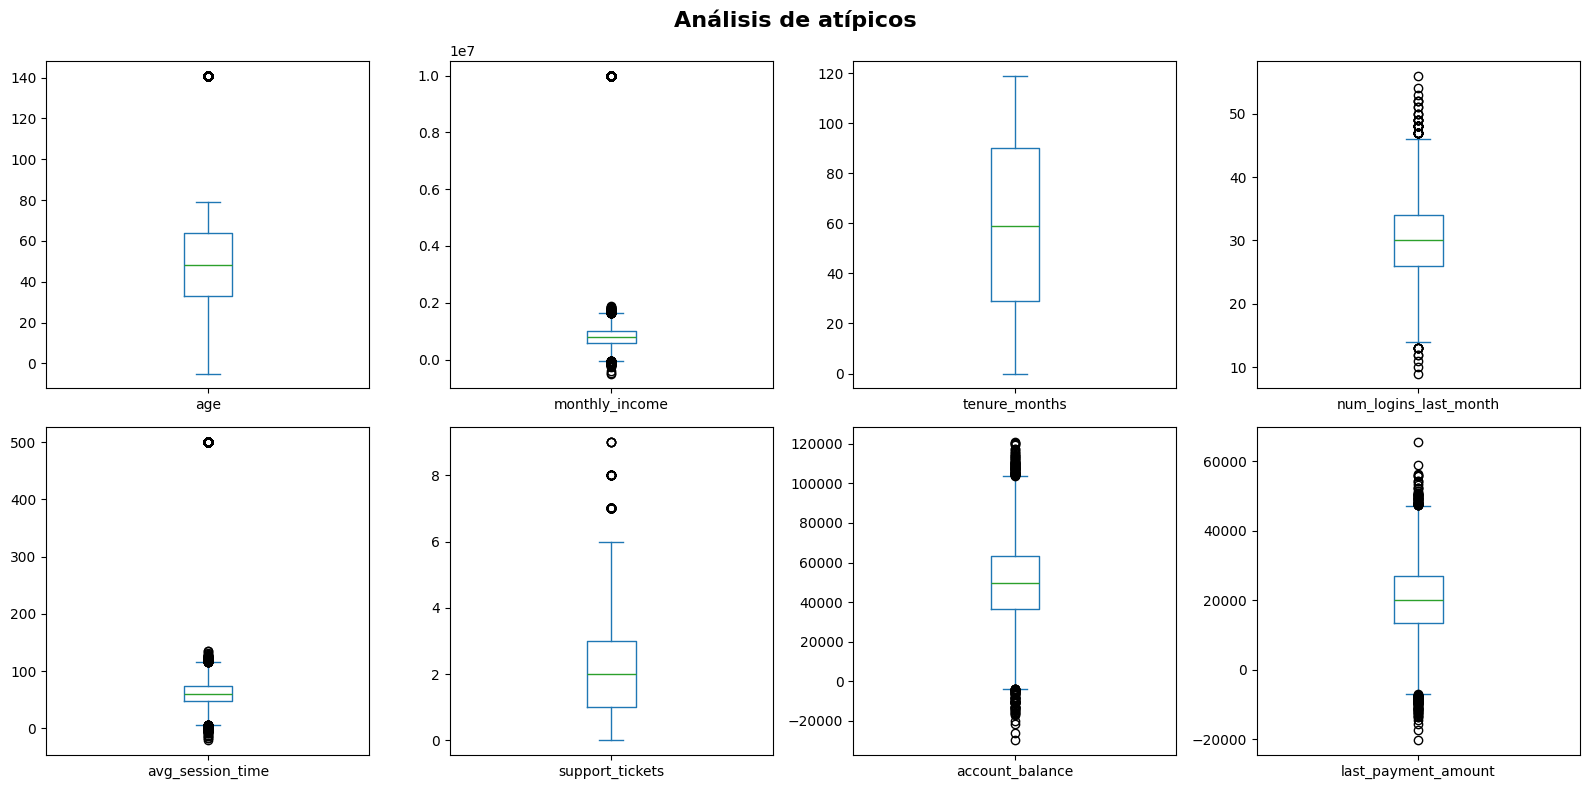

In [6]:
revision_atipicos = [
    'age', 'monthly_income', 'tenure_months', 'num_logins_last_month', 
    'avg_session_time', 'support_tickets', 'account_balance', 'last_payment_amount'
]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()  # convierte la matriz de ejes en un vector

for i, col in enumerate(revision_atipicos):
  datos[col].plot(kind='box', ax=axes[i])
  axes[i].tick_params(axis="x", labelrotation=0)

plt.suptitle("Análisis de atípicos", fontsize=16, fontweight="bold")
plt.tight_layout()

plt.show()

- En la edad \(age\), existe valores atípicos de 140 años

- En el ingreso mensual \(monthly\_income\), existen valores atípicos negativos \(bajo 0\) y valores superiores\. Se destaca un valor atípico superior que se encuentra mucho más alejado\.

- En el número de sesiones mensual \(num\_login\_last\_months\), existen valores atípicos tanto superiores como inferiores\.

- En el tiempo promedio de sesión \(avg\_session\_time\), existen valores atípicos inferiores y superiores\. Destacando un tiempo atípico superior o igual a 500 que se aleja del resto\.

- En el número de tickets \(support\_tickets\), existen valores atípicos superiores

- En el saldo de la cuenta \(account\_balance\), existen valores atípicos inferiores y superiores

- En el último pago \(last\_payment\_amount\) existen valores atípicos inferiores negativos y superiores

## Revisión de inconsistencias

### Para cuantitativas:

Definiremos las siguientes reglas de consistencia:

- age: 18 <= x <= 80\. Se asume que, para tener una cuenta, el usuario debe ser mayor de edad\. También, un límite de edad coherente de un usuario sería de 80 años, apoyándose con el gráfico de cajas donde el máximo \( < Q\_3\+1,5\(Q\_3\-Q\_1\)\)no supera esta edad\.

- monthly\_income: 0 <= x

- tenure\_months: 0 <= x

- num\_logins\_last\_month: 0 <= x

- avg\_session\_time: 0 <= x

- support\_tickets: 0 <= x

- account\_balance: 0 <= x

- last\_payment\_amount: 0 <= x

In [7]:
# Escriba su código acá
inconsistencias = datos[
    (datos['age'] < 18) | (datos['age'] > 80) |
    (datos['monthly_income'] < 0) |
    (datos['tenure_months'] < 0) |
    (datos['num_logins_last_month'] < 0) |
    (datos['avg_session_time'] < 0) |
    (datos['support_tickets'] < 0) |
    (datos['account_balance'] < 0) |
    (datos['last_payment_amount'] < 0)
]
inconsistencias

,customer_id,age,monthly_income,tenure_months,num_logins_last_month,avg_session_time,support_tickets,account_balance,last_payment_amount,gender,subscription_type,region,payment_method,is_active,preferred_device,churn
24,25,141.0,4.947750e+05,9,23,80.627878,2,92214.081686,37054.981204,Male,Enterprise,East,Transfer,Yes,Mobile,1
47,48,38.0,9.393170e+05,119,28,51.699977,3,71143.120322,-8638.523066,NaN,Premium,North,Debit Card,Yes,Desktop,1
53,54,38.0,-1.000000e+05,15,28,80.815791,3,45750.504885,26898.056970,Male,Premium,East,Credit Card,Yes,Mobile,0
59,60,38.0,6.602348e+05,9,34,47.909770,2,71055.533036,-707.350603,Male,Enterprise,East,Debit Card,No,Tablet,0
62,63,77.0,NaN,37,25,77.341020,4,-3484.853555,19584.816007,Female,Enterprise,West,PayPal,No,Tablet,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20909,2256,-5.0,4.745605e+05,22,28,57.801877,1,55557.157569,31697.060773,Other,Enterprise,North,Debit Card,No,Mobile,0
20922,7271,31.0,7.601867e+05,17,44,67.498106,1,56370.726597,-1097.518661,Female,Premium,East,Transfer,Yes,Mobile,1
20926,7888,63.0,4.528124e+05,26,45,107.170665,3,41752.594619,-1682.760110,Other,Premium,West,PayPal,Yes,Desktop,1
20927,15710,74.0,-1.000000e+05,78,39,29.099820,0,61893.441053,33285.361859,Other,Enterprise,North,PayPal,No,Mobile,0


Existen 1346 registros con inconsistencias de valores\.

### Para cualitativas

Definiremos los siguientes valores válidos

- gender: Male, Female, Other

- subscription\_type: Basic, Premium, Enterprise

- region: North, South, West, East

- payment\_method: Credit Card, Debit Card, PayPal, Transfer

- is\_active: Yes, No

- preferred\_device: Mobile, Desktop, Tablet

- churn: 0, 1

In [8]:
datos.gender.unique()

array(['Other', nan, 'Female', 'Male'], dtype=object)

In [9]:
datos.subscription_type.unique()

array(['Enterprise', 'Basic', 'Premium'], dtype=object)

In [10]:
datos.region.unique()

array(['West', 'South', 'North', 'East'], dtype=object)

In [11]:
datos.payment_method.unique()

array([nan, 'Debit Card', 'Credit Card', 'PayPal', 'Transfer'],
      dtype=object)

In [12]:
datos.is_active.unique()

array(['Yes', 'No'], dtype=object)

In [13]:
datos.preferred_device.unique()

array(['Desktop', 'Mobile', 'Tablet'], dtype=object)

In [14]:
datos.churn.unique()

array([1, 0])

De los valores categóricos, los campos gender \(género\) y payment\_method \(método de pago\) presentan inconsistencias relacionadas con valores "nan" \(nulos\)\.

## Revisión de duplicados

In [15]:
datos.duplicated().sum()

1000

Existen 1000 datos duplicados:

In [16]:
datos[datos.duplicated(keep=False)].sort_values(by='customer_id')

,customer_id,age,monthly_income,tenure_months,num_logins_last_month,avg_session_time,support_tickets,account_balance,last_payment_amount,gender,subscription_type,region,payment_method,is_active,preferred_device,churn
29,30,49.0,8.560272e+05,75,24,24.155548,1,36786.360402,24526.064563,Other,Premium,East,PayPal,Yes,Desktop,1
20808,30,49.0,8.560272e+05,75,24,24.155548,1,36786.360402,24526.064563,Other,Premium,East,PayPal,Yes,Desktop,1
53,54,38.0,-1.000000e+05,15,28,80.815791,3,45750.504885,26898.056970,Male,Premium,East,Credit Card,Yes,Mobile,0
20676,54,38.0,-1.000000e+05,15,28,80.815791,3,45750.504885,26898.056970,Male,Premium,East,Credit Card,Yes,Mobile,0
81,82,74.0,3.940678e+05,12,38,81.451588,2,73386.737914,15850.188316,Female,Enterprise,East,Transfer,No,Mobile,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20660,19974,33.0,1.128085e+06,111,25,87.790691,1,84751.539493,16273.962321,Male,Premium,North,Transfer,Yes,Mobile,0
19976,19977,66.0,5.620763e+05,108,43,61.314927,3,51434.870846,25963.712853,Other,Basic,North,PayPal,No,Mobile,0
20686,19977,66.0,5.620763e+05,108,43,61.314927,3,51434.870846,25963.712853,Other,Basic,North,PayPal,No,Mobile,0
20258,19990,53.0,7.261838e+05,93,29,91.552765,5,70170.793757,21619.638950,Other,Basic,West,PayPal,No,Mobile,0


# Limpieza y transformación

## Estadísticas antes de la limpieza

Para los datos cuantitativos, nos deshacemos de las columnas customer\_id al ser solo un identificador y de churn al ser un indicador que actúa como booleano

In [17]:
print("Estadísticas cuantitativas:")
datos.drop(columns=['customer_id','churn']).describe()

Estadísticas cuantitativas:


,age,monthly_income,tenure_months,num_logins_last_month,avg_session_time,support_tickets,account_balance,last_payment_amount
count,19964.000000,1.996200e+04,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000
mean,48.763775,8.831296e+05,59.489476,29.950524,64.593725,1.999143,49991.270494,19994.073220
std,20.781103,9.800619e+05,34.825396,5.484583,48.169755,1.411416,19927.866963,10035.594111
min,-5.000000,-4.918861e+05,0.000000,9.000000,-20.873111,0.000000,-29809.544612,-20353.769010
25%,33.000000,5.904548e+05,29.000000,26.000000,46.876785,1.000000,36437.872442,13248.528218
50%,48.000000,7.989149e+05,59.000000,30.000000,60.323748,2.000000,49778.059812,19996.930030
75%,64.000000,1.007102e+06,90.000000,34.000000,74.306634,3.000000,63433.887216,26828.259187
max,141.000000,1.000000e+07,119.000000,56.000000,500.000000,9.000000,120775.517228,65425.194812


Aquí se notan mejor las inconsistencias de datos como la edad \(\-5 y 141 años\) y campos de ingresos o temporales con mínimos negativos\. Además, podemos ver valores atípicos, como en el campo avg\_session\_time, con un máximo de 500, o en el campo tickets, con un máximo de 9, cuando el tercer cuartil es de 3 tickets\.

In [18]:
print("Estadísticas cualitativas:")
datos.describe(include='object')

Estadísticas cualitativas:


,gender,subscription_type,region,payment_method,is_active,preferred_device
count,19947,21000,21000,19953,21000,21000
unique,3,3,4,4,2,3
top,Other,Enterprise,East,PayPal,Yes,Mobile
freq,6763,7039,5316,5054,10523,7089


In [19]:
datos['churn'].astype('object').describe()

count     21000
unique        2
top           0
freq      14666
Name: churn, dtype: int64

De los valores cualitativos, no se puede decir mucho con respecto a los datos más allá de la moda\.

### Tratamiento de inconsistencias

Primero, tratamos las inconsistencias recortando los valores de tiempo y de dinero negativos a 0\. Para la edad, recortaremos los valores al valor mínimo \(18 años\) y al máximo \(80 años\)

In [20]:
datos['age'] = datos['age'].clip(lower=18, upper=80)
columnas_numericas = ['monthly_income', 'tenure_months', 'num_logins_last_month', 'avg_session_time', 'support_tickets', 'account_balance', 'last_payment_amount']
datos[columnas_numericas] = datos[columnas_numericas].clip(lower=0)
datos

,customer_id,age,monthly_income,tenure_months,num_logins_last_month,avg_session_time,support_tickets,account_balance,last_payment_amount,gender,subscription_type,region,payment_method,is_active,preferred_device,churn
0,1,39.0,NaN,76,42,30.297419,0,70965.479058,47431.757551,Other,Enterprise,West,NaN,Yes,Desktop,1
1,2,69.0,1.352838e+06,46,27,50.666766,3,62653.316701,26134.009301,Other,Basic,South,Debit Card,No,Mobile,1
2,3,NaN,9.127957e+05,83,23,53.086839,1,46918.415548,15390.195033,NaN,Enterprise,West,NaN,No,Mobile,0
3,4,79.0,7.955275e+05,45,23,55.197774,1,22665.546094,41163.281718,Female,Premium,South,Debit Card,No,Tablet,1
4,5,52.0,4.425135e+05,98,29,67.781999,3,58510.036769,14704.401069,Male,Basic,West,Credit Card,Yes,Mobile,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20995,17722,59.0,9.212134e+05,6,32,55.690940,4,107772.068497,17055.825833,Other,Premium,West,Credit Card,No,Desktop,0
20996,3461,23.0,6.824455e+05,63,36,64.531197,1,71619.219699,8880.655722,Female,Premium,North,Credit Card,Yes,Desktop,1
20997,3543,68.0,6.372404e+05,18,35,53.606069,1,38335.532706,28256.446769,Male,Enterprise,West,PayPal,No,Tablet,1
20998,18023,24.0,4.356965e+05,25,41,72.408040,0,57249.809484,10264.357562,Other,Basic,East,Credit Card,No,Mobile,0


### Ingeniería de características

Definiremos tres características adicionales:

In [21]:
def feature_engineering(data: pd.DataFrame):
    """
        Realiza ingeniería de características

        Parámetros
        ----------
        data: DataFrame conteniendo los datos

        Retorno
        -------
        DataFrame con las nuevas características:
            Sí
    """
    data = data.copy()
    data["payment_income_ratio"] = np.where(
        data["monthly_income"] != 0,
        data["last_payment_amount"] / data["monthly_income"],
        0
    )
    data["balance_payment_ratio"] = np.where(
        data["last_payment_amount"] != 0,
        data["account_balance"] / data["last_payment_amount"],
        0
    )
    data['ticket_tenure_ratio'] = data["support_tickets"] / (data["tenure_months"] + 1)
    return data

In [22]:
datos_fe = feature_engineering(datos.copy())
datos_fe.head()

,customer_id,age,monthly_income,tenure_months,num_logins_last_month,avg_session_time,support_tickets,account_balance,last_payment_amount,gender,subscription_type,region,payment_method,is_active,preferred_device,churn,payment_income_ratio,balance_payment_ratio,ticket_tenure_ratio
0,1,39.0,NaN,76,42,30.297419,0,70965.479058,47431.757551,Other,Enterprise,West,NaN,Yes,Desktop,1,NaN,1.496160,0.000000
1,2,69.0,1.352838e+06,46,27,50.666766,3,62653.316701,26134.009301,Other,Basic,South,Debit Card,No,Mobile,1,0.019318,2.397386,0.063830
2,3,NaN,9.127957e+05,83,23,53.086839,1,46918.415548,15390.195033,NaN,Enterprise,West,NaN,No,Mobile,0,0.016861,3.048591,0.011905
3,4,79.0,7.955275e+05,45,23,55.197774,1,22665.546094,41163.281718,Female,Premium,South,Debit Card,No,Tablet,1,0.051743,0.550625,0.021739
4,5,52.0,4.425135e+05,98,29,67.781999,3,58510.036769,14704.401069,Male,Basic,West,Credit Card,Yes,Mobile,0,0.033229,3.979083,0.030303


Agregamos las características de diferencia entre ingreso mensual y último pago \(gap\_income\_payment\) y de horas estimadas de sesión en el último mes \(estimated\_last\_month\_session\_hours\)\.

### Análisis de correlación

Adaptamos valores categóricos a indicadores:

In [23]:
datos_correlacion = pd.get_dummies(
    datos_fe,
    columns=["gender", "subscription_type", "region","payment_method","is_active","preferred_device"],
    drop_first=True
)

Luego, analizamos los campos con respecto al indicador de abandono churn:

In [24]:
correlaciones = datos_correlacion.drop(columns=["customer_id"]).corr()["churn"].round(4)
correlaciones

age                             0.0027
monthly_income                 -0.0004
tenure_months                   0.0004
num_logins_last_month          -0.0025
avg_session_time                0.0014
support_tickets                -0.0006
account_balance                -0.0063
last_payment_amount            -0.0049
churn                           1.0000
payment_income_ratio           -0.0101
balance_payment_ratio           0.0027
ticket_tenure_ratio             0.0067
gender_Male                     0.0167
gender_Other                   -0.0208
subscription_type_Enterprise    0.0079
subscription_type_Premium      -0.0127
region_North                    0.0039
region_South                   -0.0087
region_West                     0.0015
payment_method_Debit Card       0.0037
payment_method_PayPal           0.0113
payment_method_Transfer        -0.0002
is_active_Yes                   0.0008
preferred_device_Mobile        -0.0112
preferred_device_Tablet         0.0003
Name: churn, dtype: float

De aquí no se puede extraer correlaciones claras \(los valores absolutos son menores a 0,1\)\. Lo que, en parte, puede deberse a que los datos están sucios \(valores nulos y negativos\)

Ahora creamos un gráfico que represente todas las correlaciones entre las variables:

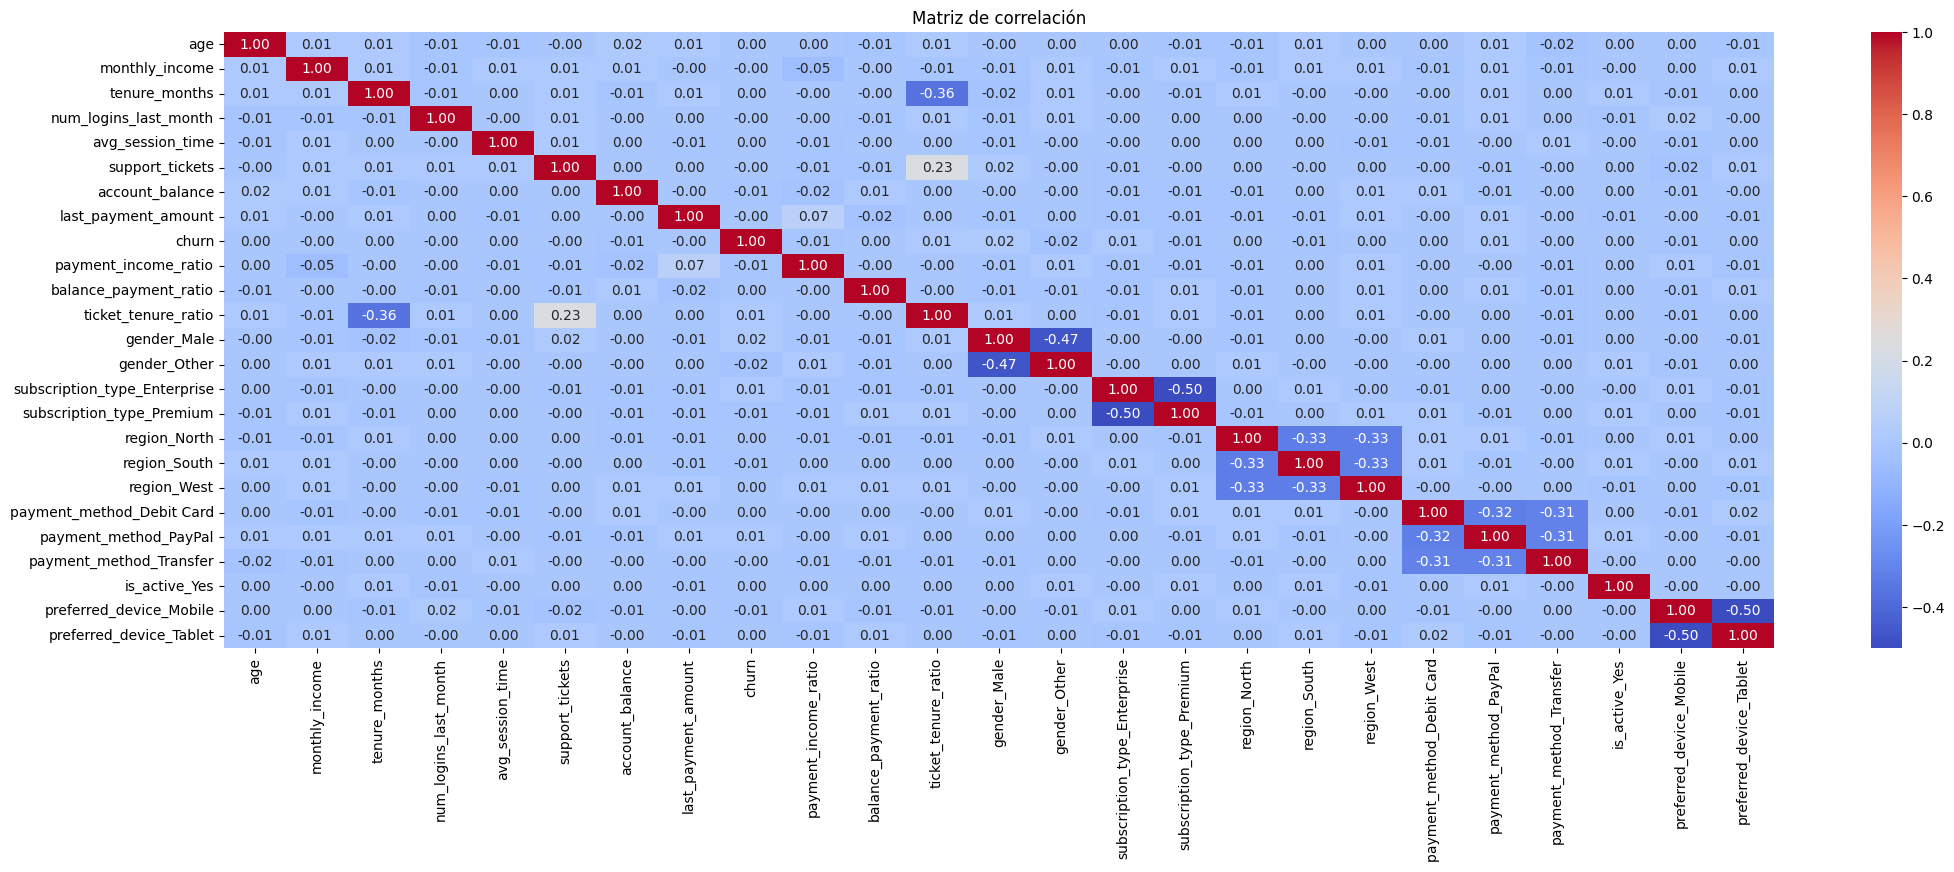

In [25]:
correlaciones = datos_correlacion.drop(columns=["customer_id"]).corr().round(2)
plt.figure(figsize=(25, 8))
sb.heatmap(correlaciones, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación") 
plt.show()

De la matriz se puede decir que hay una gran dispersión de datos, ya que, aparte de haber valores bajo, las características nuevas también tienen baja correlación\. Desde la proporción entre el balance de cuenta y el último pago \(no superan en 0\.02\) hasta la proporción entre número de tickets y antigüedad del usuario \(donde los meses de antigüedad tienen mayor correlación \(absoluta\) de un \-0\.36 y el número de tickets un 0\.23\)\.

## Limpieza de datos

### Definición de funciones y variables de limpieza

La winsorización es una técnica en la cual se transforman valores atípicos de un campo a los límites de un rango establecido\. Lo común es fijar los límites inferiores y superiores al percentil 5 y 95 respectivamente \(como en la función de abajo\)\.

Aplicaremos este proceso para eliminar los atípicos de las variables cuantitativas y así tener un promedio más representativo con el cual imputar los valores nulos\. Con el costo de perder, en parte, la fidelidad de los datos originales\.

In [26]:
class Winsorizer(BaseEstimator, TransformerMixin):
  """
  Tratamiento de atípicos

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  columns_ : array-like
    Nombres de las columnas a transformar.
  limits : tuple
    % de los extremos a descartar
  """
  # Recortar 5% inferior y superior de los datos
  def __init__(self, limits=(0.05, 0.05)):
    self.limits = limits

  def fit(self, X, y=None):
    # Guardar nombres si es DataFrame, si no generar nombres genéricos
    if isinstance(X, pd.DataFrame):
      self.columns_ = X.columns
    else:
      self.columns_ = np.arange(X.shape[1])
    return self

  # Transformacion de los datos
  def transform(self, X):
    X = pd.DataFrame(X, columns=self.columns_)
    X = X.astype("float64")
    for col in self.columns_:
      lower = X[col].quantile(self.limits[0]) # Valor percentil 5
      upper = X[col].quantile(1 - self.limits[1]) # Valor percentil 95
      X[col] = np.clip(X[col], lower, upper)
    return X

  def get_feature_names_out(self, input_features=None):
    if input_features is None:
      return np.array(self.columns_)
    else:
      return np.array(input_features)

Como el dataset cuenta con un identificador de las tuplas, es seguro eliminar los datos duplicados al saber que cada cliente es único y que la eliminación de los duplicados mejorará la calidad de estos\.

In [27]:
def eliminar_duplicados(X : pd.DataFrame):
    """
    Elimina tuplas duplicadas

    Parámetros
    ----------

    X: set de datos

    Retorno
    -------
    Nuevo set de datos sin los duplicados

    """
    return X.drop_duplicates()

Creamos la variable X como una copia de los datos con el feature engineering aplicado sin la columna de id del cliente ni la variable churn\. Esto con el fin de realizar las limpiezas sobre esta tabla\. Para los valores de churn, lo guardaremos en una variable Y al no tener que modificarlo\.

In [28]:
X = datos.drop(columns=['customer_id','churn'])
Y = datos['churn']

Definimos los arreglos que contienen los nombres de las columnas con valores cuantitativos y cualitativos

In [29]:
numeric_features = [
    'age', 'monthly_income', 'tenure_months', 'num_logins_last_month', 'avg_session_time', 
    'support_tickets', 'account_balance', 'last_payment_amount'
]
categorical_features = [
    'gender', 'subscription_type', 'region', 'payment_method', 'is_active', 'preferred_device'
]

Después, creamos la pipeline encargada de limpiar y transformar las variables cuantitativas con los pasos:

- winsorizer: ajustamos los valores atípicos con la winsorización para obtener un promedio más representativo

- imputacion: Imputa los valores nulos teniendo de estrategia el reemplazarlos por el promedio ya ajustado

- escalado: Escala los valores para que el tamaño de las variables no afecten en el modelado

In [30]:
pipeline_numerico = Pipeline(
    steps=[
        ("winsorizer", Winsorizer()),
        ("imputacion", SimpleImputer(strategy="mean")),
        ("escalado", StandardScaler())
    ]
)

También creamos la pipeline encargada de limpiar y transformar las variables cualitativas con los pasos:

- imputacion: Imputa los valores nulos teniendo de estrategia el reemplazarlos por el valor más frecuente \(la moda\)

- encoder: Transforma los valores categóricos en diferentes columnas booleanas\. Necesaria para el modelado considerando que este no entiende textos como tal\.

In [31]:
pipeline_categorico = Pipeline(
    steps=[
        ("imputacion", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(sparse_output=False, handle_unknown="ignore"))
    ]
)

Se define el preprocesador, el cual se encargará de transformar la columnas con las pipelines de limpiezas cuantitativas "num" y cualitativas 'cat'\.

In [32]:
preprocesador = ColumnTransformer(
    transformers=[
        ("num", pipeline_numerico, numeric_features),
        ("cat", pipeline_categorico, categorical_features)
    ]
)

Finalmente, se define la pipeline de limpieza y preparación para la transformación con los pasos:

- duplicados: remueve los registros duplicados

- feauture\_egnineering: Aplica la función de fe a la tabla

- preprocesamiento: Termina de limpiar las columnas de valores cuantitativos y cualitativos

In [33]:
pipeline_limpieza_transformacion = Pipeline(
    steps=[
        ("duplicados", FunctionTransformer(eliminar_duplicados)),
        ("feature_engineering", FunctionTransformer(feature_engineering)),
        ("preprocesamiento", preprocesador)
    ]
)

Se aplica la limpieza en X y almacenamos los resultados en X\_clean:

In [34]:
X_clean = pipeline_limpieza_transformacion.fit_transform(X)

Finalmente, transformamos los resultados en un DataFrame y lo almacenamos en data\_clean, Luego, establecemos los nombres de las columnas basándonos en el resultados entregados por el preprocesador de la pipeline y aseguramos el tipo de dato de los valores cuantitativos\.

In [35]:
data_clean = pd.DataFrame(
    X_clean,
    columns=pipeline_limpieza_transformacion.named_steps["preprocesamiento"].get_feature_names_out()
)

# Setea el nombre de las columnas
data_clean.columns = data_clean.columns.str.replace("num__", "")
data_clean.columns = data_clean.columns.str.replace("cat__", "")
data_clean['churn'] = Y
data_clean[numeric_features] = data_clean[numeric_features].apply(pd.to_numeric)

Ahora, comprobamos los resultados de los datos limpios:

In [36]:
data_clean.head()

,age,monthly_income,tenure_months,num_logins_last_month,avg_session_time,support_tickets,account_balance,last_payment_amount,gender_Female,gender_Male,...,payment_method_Credit Card,payment_method_Debit Card,payment_method_PayPal,payment_method_Transfer,is_active_No,is_active_Yes,preferred_device_Desktop,preferred_device_Mobile,preferred_device_Tablet,churn
0,-0.533781,0.000000,0.478751,1.819776,-1.627287,-1.462108,1.154006,1.794273,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1
1,1.179584,1.873115,-0.395436,-0.579494,-0.534592,0.753319,0.696641,0.669010,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1
2,0.000000,0.407393,0.682728,-1.379250,-0.404769,-0.723633,-0.169151,-0.504737,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0
3,1.636482,-0.010693,-0.424575,-1.379250,-0.291530,-0.723633,-1.503632,1.794273,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1
4,0.208677,-1.269265,1.119822,-0.179615,0.383539,0.753319,0.468662,-0.579659,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0


In [37]:
data_clean.shape

(20000, 28)

In [38]:
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   age                           20000 non-null  float64
 1   monthly_income                20000 non-null  float64
 2   tenure_months                 20000 non-null  float64
 3   num_logins_last_month         20000 non-null  float64
 4   avg_session_time              20000 non-null  float64
 5   support_tickets               20000 non-null  float64
 6   account_balance               20000 non-null  float64
 7   last_payment_amount           20000 non-null  float64
 8   gender_Female                 20000 non-null  float64
 9   gender_Male                   20000 non-null  float64
 10  gender_Other                  20000 non-null  float64
 11  subscription_type_Basic       20000 non-null  float64
 12  subscription_type_Enterprise  20000 non-null  float64
 13  s

In [39]:
data_clean.describe()

,age,monthly_income,tenure_months,num_logins_last_month,avg_session_time,support_tickets,account_balance,last_payment_amount,gender_Female,gender_Male,...,payment_method_Credit Card,payment_method_Debit Card,payment_method_PayPal,payment_method_Transfer,is_active_No,is_active_Yes,preferred_device_Desktop,preferred_device_Mobile,preferred_device_Tablet,churn
count,2.000000e+04,2.000000e+04,2.000000e+04,2.000000e+04,2.000000e+04,2.000000e+04,2.000000e+04,2.000000e+04,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000
mean,-3.979039e-17,-1.627143e-16,2.557954e-17,-1.211475e-16,-2.945200e-16,4.973799e-17,-1.215028e-16,1.051603e-16,0.314250,0.313900,...,0.233650,0.239050,0.289450,0.237850,0.49855,0.50145,0.328950,0.336850,0.334200,0.301750
std,1.000025e+00,1.000025e+00,1.000025e+00,1.000025e+00,1.000025e+00,1.000025e+00,1.000025e+00,1.000025e+00,0.464228,0.464088,...,0.423163,0.426514,0.453518,0.425777,0.50001,0.50001,0.469844,0.472645,0.471722,0.459029
min,-1.618912e+00,-1.888753e+00,-1.561018e+00,-1.779129e+00,-1.777220e+00,-1.462108e+00,-1.782553e+00,-1.809170e+00,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,-8.764537e-01,-6.962278e-01,-8.908083e-01,-7.794328e-01,-7.362518e-01,-7.236325e-01,-7.441003e-01,-7.377835e-01,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000
50%,0.000000e+00,0.000000e+00,-1.662121e-02,2.032382e-02,-1.408862e-02,1.484337e-02,-1.180279e-02,-1.177889e-03,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,1.00000,0.000000,0.000000,0.000000,0.000000
75%,8.369113e-01,7.013011e-01,8.867054e-01,8.200805e-01,7.307914e-01,7.533193e-01,7.384444e-01,7.461054e-01,1.000000,1.000000,...,0.000000,0.000000,1.000000,0.000000,1.00000,1.00000,1.000000,1.000000,1.000000,1.000000
max,1.636482e+00,1.873115e+00,1.586055e+00,1.819776e+00,1.851309e+00,2.230271e+00,1.814170e+00,1.794273e+00,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.00000,1.00000,1.000000,1.000000,1.000000,1.000000


### Análisis de correlación post limpieza

Ahora volvemos a analizar los campos con respecto al indicador de abandono churn:

In [40]:
correlaciones = data_clean.corr()["churn"].round(4)
correlaciones

age                             0.0021
monthly_income                  0.0025
tenure_months                   0.0014
num_logins_last_month          -0.0023
avg_session_time               -0.0016
support_tickets                 0.0007
account_balance                -0.0050
last_payment_amount            -0.0017
gender_Female                   0.0055
gender_Male                     0.0187
gender_Other                   -0.0232
subscription_type_Basic         0.0057
subscription_type_Enterprise    0.0069
subscription_type_Premium      -0.0126
region_East                     0.0042
region_North                    0.0033
region_South                   -0.0082
region_West                     0.0007
payment_method_Credit Card     -0.0098
payment_method_Debit Card       0.0039
payment_method_PayPal           0.0058
payment_method_Transfer        -0.0004
is_active_No                   -0.0004
is_active_Yes                   0.0004
preferred_device_Desktop        0.0106
preferred_device_Mobile  

De aquí no se puede extraer correlaciones claras \(los valores absolutos son menores a 0,1\)\. Lo que, en parte, puede deberse a que los datos están sucios \(valores nulos y negativos\)

Ahora creamos un gráfico que represente todas las correlaciones entre las variables:

In [ ]:
correlaciones = data_clean.corr().round(2)
plt.figure(figsize=(25, 10))
sb.heatmap(correlaciones, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación") 
plt.show()

De la matriz se obtiene una mejora de correlación entre variables, resultado de la limpieza de nulos e inconsistencias\. Pero la variable churn sigue sin presentar alguna correlación con el resto de las variables\.

# Guarda set de datos limpio y transformado

Finalmente, guardados los datos limpios como "dataset\_churn\_clear\.csv"

In [48]:
data_clean.to_csv('dataset_churn_clear.csv')

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=d68a5e3d-989d-40b3-931c-b38c67cd1515' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>